In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from glob import glob
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
class Config:

    BASE_DIR = "D:\chest_xray"
    TRAIN_DIR = os.path.join(BASE_DIR, 'train')
    VAL_DIR = os.path.join(BASE_DIR, 'val')
    TEST_DIR = os.path.join(BASE_DIR, 'test')
    
    #parameters
    IMG_HEIGHT = 224
    IMG_WIDTH = 224
    IMG_CHANNELS = 3
    IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
    
    #hyperparameters
    BATCH_SIZE = 32
    EPOCHS = 10
    LEARNING_RATE = 1e-4
    EARLY_STOPPING_PATIENCE = 10
    REDUCE_LR_PATIENCE = 5
    
    # Model architecture
    DROPOUT_RATE = 0.5
    L2_REGULARIZATION = 0.001
    
    # Classes
    CLASSES = ['NORMAL', 'PNEUMONIA']
    NUM_CLASSES = len(CLASSES)
    
    OUTPUT_DIR = './outputs'
    MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, 'pneumonia_detection_model.h5')

os.makedirs(Config.OUTPUT_DIR, exist_ok=True)



Dataset Distribution:
Split           Normal          Pneumonia       Total          
------------------------------------------------------------
Training        1341            3875            5216           
Validation      8               8               16             
Testing         234             390             624            
------------------------------------------------------------
TOTAL           1583            4273            5856           


Class Imbalance Analysis:
Training set - Pneumonia:Normal ratio = 2.89:1
Dataset sample images


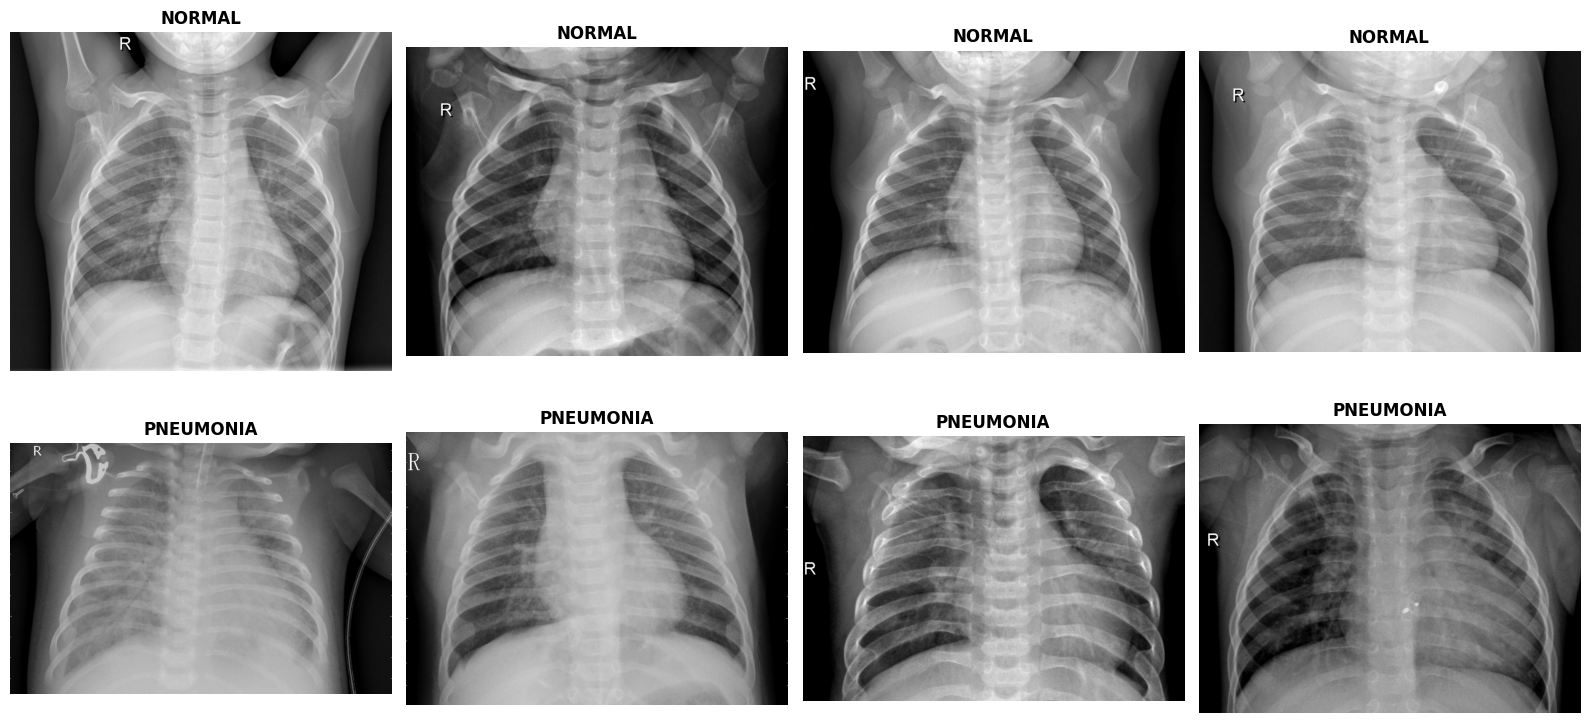

In [3]:

def show_dataset():
    train_normal = len(glob(os.path.join(Config.TRAIN_DIR, 'NORMAL', '*')))
    train_pneumonia = len(glob(os.path.join(Config.TRAIN_DIR, 'PNEUMONIA', '*')))
    val_normal = len(glob(os.path.join(Config.VAL_DIR, 'NORMAL', '*')))
    val_pneumonia = len(glob(os.path.join(Config.VAL_DIR, 'PNEUMONIA', '*')))
    test_normal = len(glob(os.path.join(Config.TEST_DIR, 'NORMAL', '*')))
    test_pneumonia = len(glob(os.path.join(Config.TEST_DIR, 'PNEUMONIA', '*')))
    
    print(f"\nDataset Distribution:")
    print(f"{'Split':<15} {'Normal':<15} {'Pneumonia':<15} {'Total':<15}")
    print("-"*60)
    print(f"{'Training':<15} {train_normal:<15} {train_pneumonia:<15} {train_normal + train_pneumonia:<15}")
    print(f"{'Validation':<15} {val_normal:<15} {val_pneumonia:<15} {val_normal + val_pneumonia:<15}")
    print(f"{'Testing':<15} {test_normal:<15} {test_pneumonia:<15} {test_normal + test_pneumonia:<15}")
    print("-"*60)
    
    total = train_normal + train_pneumonia + val_normal + val_pneumonia + test_normal + test_pneumonia
    print(f"{'TOTAL':<15} {train_normal + val_normal + test_normal:<15} "
          f"{train_pneumonia + val_pneumonia + test_pneumonia:<15} {total:<15}")
    
    print(f"\n\nClass Imbalance Analysis:")
    train_imbalance = train_pneumonia / train_normal
    print(f"Training set - Pneumonia:Normal ratio = {train_imbalance:.2f}:1")
    
    print(f"Dataset sample images")
    visualize_samples()
    
    return {
        'train': (train_normal, train_pneumonia),
        'val': (val_normal, val_pneumonia),
        'test': (test_normal, test_pneumonia)
    }

def visualize_samples():    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    #normal
    normal_imgs = glob(os.path.join(Config.TRAIN_DIR, 'NORMAL', '*.jpeg'))[:4]
    for idx, img_path in enumerate(normal_imgs):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[0, idx].imshow(img)
        axes[0, idx].set_title('NORMAL', fontsize=12, fontweight='bold')
        axes[0, idx].axis('off')
    
    #pneumonia
    pneumonia_imgs = glob(os.path.join(Config.TRAIN_DIR, 'PNEUMONIA', '*.jpeg'))[:4]
    for idx, img_path in enumerate(pneumonia_imgs):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[1, idx].imshow(img)
        axes[1, idx].set_title('PNEUMONIA', fontsize=12, fontweight='bold')
        axes[1, idx].axis('off')
    
    plt.tight_layout()
    plt.show()

dataset_info = show_dataset()

In [ ]:

#data preprocessing and augmentation

def create_data_generators():

    print("\n" + "="*80)
    print("DATA PREPROCESSING AND AUGMENTATION")
    print("="*80)
    
    train_datagen = ImageDataGenerator(
        rescale=1./255,       
        rotation_range=15,              
        width_shift_range=0.1,       
        height_shift_range=0.1,     
        shear_range=0.1,             
        zoom_range=0.1,              
        horizontal_flip=True,      
        fill_mode='nearest',               
        brightness_range=[0.8, 1.2]        
    )
    
    val_test_datagen = ImageDataGenerator(rescale=1./255)
    
    train_generator = train_datagen.flow_from_directory(
        Config.TRAIN_DIR,
        target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE,
        class_mode='binary',
        shuffle=True,
        seed=42
    )
    
    val_generator = val_test_datagen.flow_from_directory(
        Config.VAL_DIR,
        target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
    
    test_generator = val_test_datagen.flow_from_directory(
        Config.TEST_DIR,
        target_size=Config.IMG_SIZE,
        batch_size=Config.BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
    
    print("\nData Generators Created Successfully:")
    print(f"Training samples: {train_generator.samples}")
    print(f"Validation samples: {val_generator.samples}")
    print(f"Test samples: {test_generator.samples}")
    print(f"\nClass indices: {train_generator.class_indices}")
    
    return train_generator, val_generator, test_generator

train_gen, val_gen, test_gen = create_data_generators()



DATA PREPROCESSING AND AUGMENTATION
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Data Generators Created Successfully:
Training samples: 5216
Validation samples: 16
Test samples: 624

Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:

def build_custom_cnn():
    
    model = models.Sequential([
        # Input layer
        layers.Input(shape=(Config.IMG_HEIGHT, Config.IMG_WIDTH, Config.IMG_CHANNELS)),
        
      
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # global pooling
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu', 
                    kernel_regularizer=keras.regularizers.l2(Config.L2_REGULARIZATION)),
        layers.BatchNormalization(),
        layers.Dropout(Config.DROPOUT_RATE),
        layers.Dense(256, activation='relu',
                    kernel_regularizer=keras.regularizers.l2(Config.L2_REGULARIZATION)),
        layers.BatchNormalization(),
        layers.Dropout(Config.DROPOUT_RATE),
        
        # Output layer
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

def compile_model(model, train_generator):
    
    print("\n" + "="*80)
    print("MODEL COMPILATION")
    print("="*80)
    
    # class imbalance
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(train_generator.classes),
        y=train_generator.classes
    )
    class_weight_dict = dict(enumerate(class_weights))
    
    print(f"\nClass weights (to handle imbalance): {class_weight_dict}")
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=Config.LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')
        ]
    )
    
    print("\nModel compiled successfully!")
    print(f"\nOptimizer: Adam (lr={Config.LEARNING_RATE})")
    print(f"Loss function: Binary Crossentropy")
    print(f"Metrics: Accuracy, Precision, Recall, AUC")
    
    return class_weight_dict

# Run section 4 (using custom CNN by default)
model = build_custom_cnn()
print("\nModel: Custom CNN Architecture")
model.summary()
class_weights = compile_model(model, train_gen)



Model: Custom CNN Architecture


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,442,337 (5.50 MB)

 Trainable params: 1,438,881 (5.49 MB)

 Non-trainable params: 3,456 (13.50 KB)


MODEL COMPILATION

Class weights (to handle imbalance): {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}

Model compiled successfully!

Optimizer: Adam (lr=0.0001)
Loss function: Binary Crossentropy
Metrics: Accuracy, Precision, Recall, AUC


In [6]:
# Traning the model
def train_model(model, train_gen, val_gen, class_weights):
    """Train the model with callbacks"""
    
    print("\n" + "="*80)
    print("MODEL TRAINING")
    print("="*80)
    
    # Define callbacks
    early_stopping = callbacks.EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=Config.EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=Config.REDUCE_LR_PATIENCE,
        min_lr=1e-7,
        verbose=1
    )
    
    model_checkpoint = callbacks.ModelCheckpoint(
        Config.MODEL_SAVE_PATH,
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    )
    
    # Train the model
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=Config.EPOCHS,
        class_weight=class_weights,
        callbacks=[early_stopping, reduce_lr, model_checkpoint],
        verbose=1
    )
    
    return history

# Run section 5
history = train_model(model, train_gen, val_gen, class_weights)



MODEL TRAINING
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6953 - auc: 0.8207 - loss: 1.2619 - precision: 0.9156 - recall: 0.6462
Epoch 1: val_auc improved from None to 0.43750, saving model to ./outputs\pneumonia_detection_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 626s 4s/step - accuracy: 0.7477 - auc: 0.8735 - loss: 1.1716 - precision: 0.9478 - recall: 0.6988 - val_accuracy: 0.5000 - val_auc: 0.4375 - val_loss: 1.5390 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7964 - auc: 0.9143 - loss: 1.0575 - precision: 0.9626 - recall: 0.7587
Epoch 2: val_auc improved from 0.43750 to 0.65625, saving model to ./outputs\pneumonia_detection_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 607s 4s/step - accuracy: 0.8066 - auc: 0.9152 - loss: 1.0444 - precision: 0.9623 - recall: 0.7698 - val_accuracy: 0.5000 - val_auc: 0.6562 - val_loss: 3.3657 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8326 - auc: 0.9372 - loss: 0.9627 - precision: 0.9722 - recall: 0.7965
Epoch 3: val_auc improved from 0.65625 to 0.70312, saving model to ./outputs\pneumonia_detection_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 653s 4s/step - accuracy: 0.8424 - auc: 0.9387 - loss: 0.9504 - precision: 0.9719 - recall: 0.8114 - val_accuracy: 0.5000 - val_auc: 0.7031 - val_loss: 2.4743 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8652 - auc: 0.9502 - loss: 0.8969 - precision: 0.9737 - recall: 0.8389
Epoch 4: val_auc improved from 0.70312 to 0.89062, saving model to ./outputs\pneumonia_detection_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 631s 4s/step - accuracy: 0.8614 - auc: 0.9499 - loss: 0.8961 - precision: 0.9704 - recall: 0.8390 - val_accuracy: 0.5000 - val_auc: 0.8906 - val_loss: 2.6039 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8586 - auc: 0.9432 - loss: 0.9045 - precision: 0.9590 - recall: 0.8448
Epoch 5: val_auc did not improve from 0.89062
163/163 ━━━━━━━━━━━━━━━━━━━━ 616s 4s/step - accuracy: 0.8762 - auc: 0.9550 - loss: 0.8629 - precision: 0.9681 - recall: 0.8617 - val_accuracy: 0.6875 - val_auc: 0.8672 - val_loss: 1.0872 - val_precision: 0.6667 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8940 - auc: 0.9653 - loss: 0.8277 - precision: 0.9761 - recall: 0.8798
Epoch 6: val_auc did not improve from 0.89062
163/163 ━━━━━━━━━━━━━━━━━━━━ 638s 4s/step - accuracy: 0.8988 - auc: 0.9663 - loss: 0.8145 - precision: 0.9764 - reca

163/163 ━━━━━━━━━━━━━━━━━━━━ 656s 4s/step - accuracy: 0.9270 - auc: 0.9776 - loss: 0.7200 - precision: 0.9778 - recall: 0.9226 - val_accuracy: 0.8125 - val_auc: 0.9219 - val_loss: 0.8999 - val_precision: 0.8571 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 10.


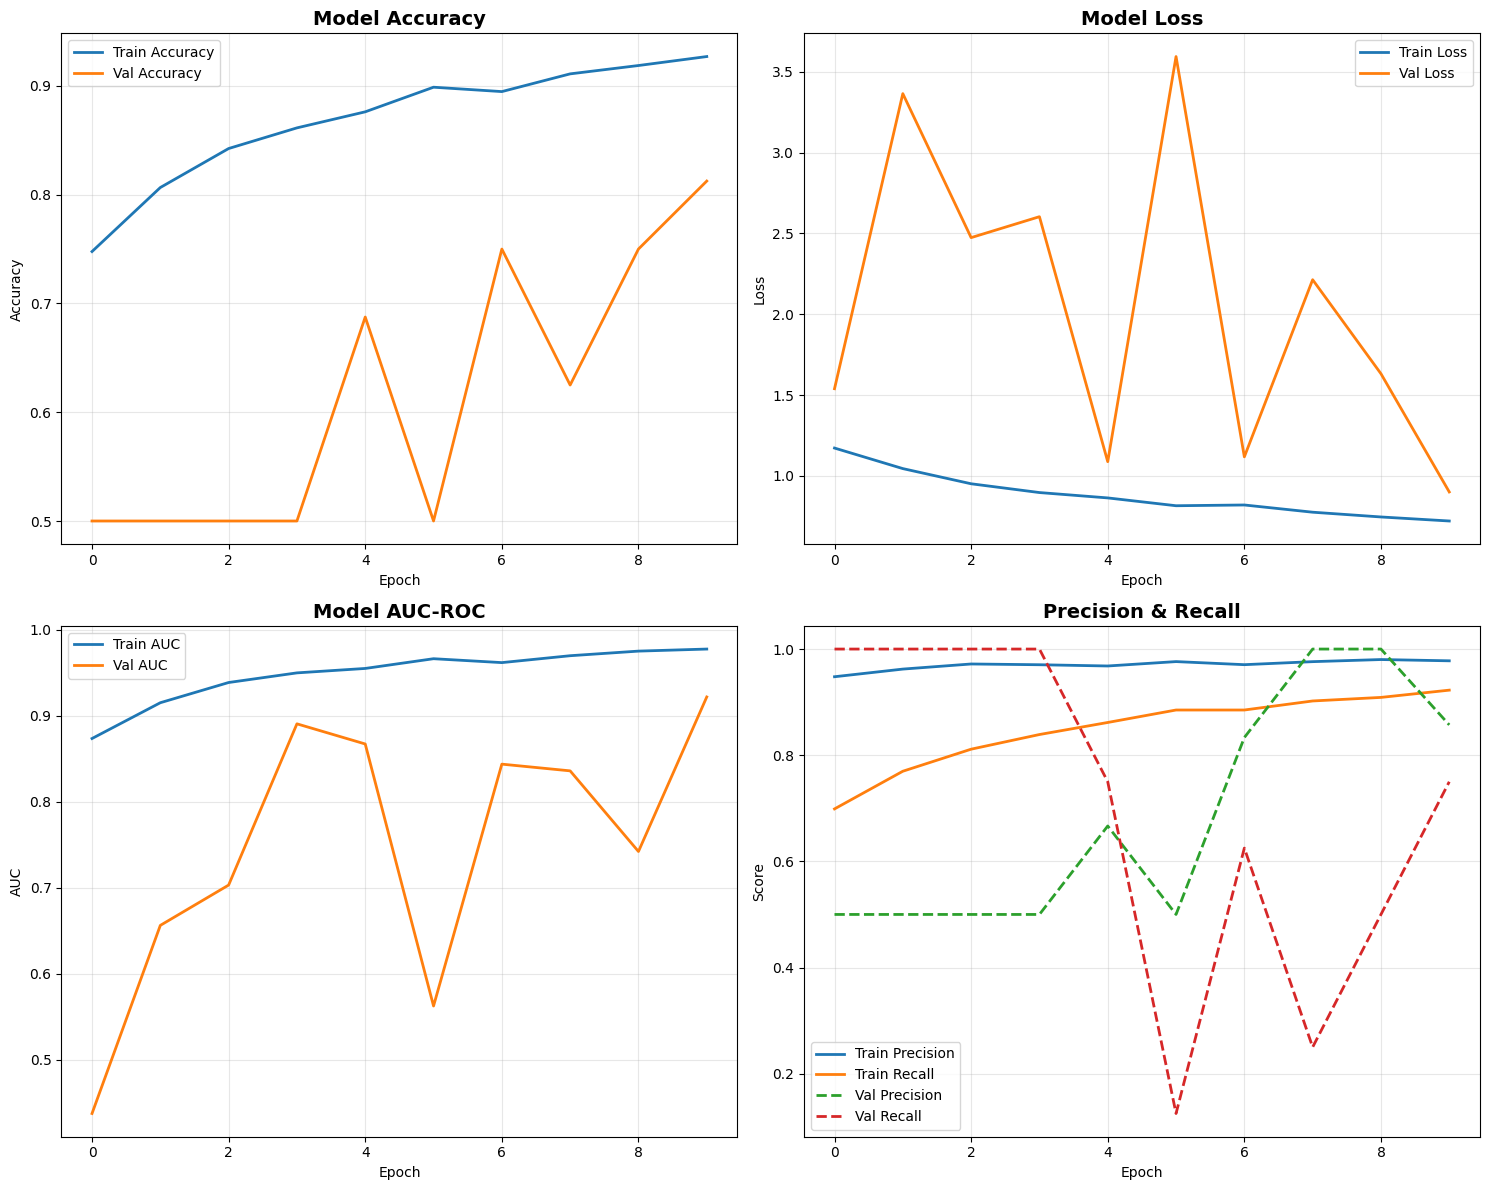


MODEL EVALUATION ON TEST SET
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 980ms/step

Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

      NORMAL     0.8061    0.9060    0.8531       234
   PNEUMONIA     0.9391    0.8692    0.9028       390

    accuracy                         0.8830       624
   macro avg     0.8726    0.8876    0.8780       624
weighted avg     0.8892    0.8830    0.8842       624



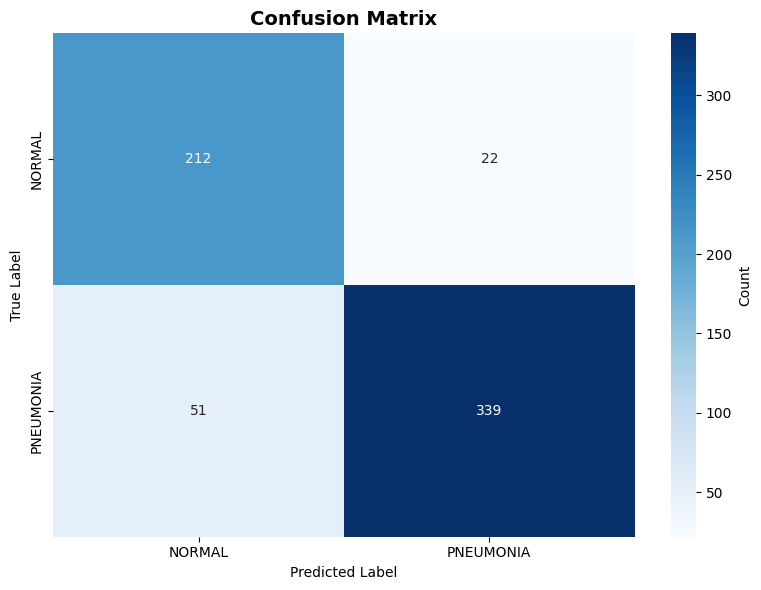

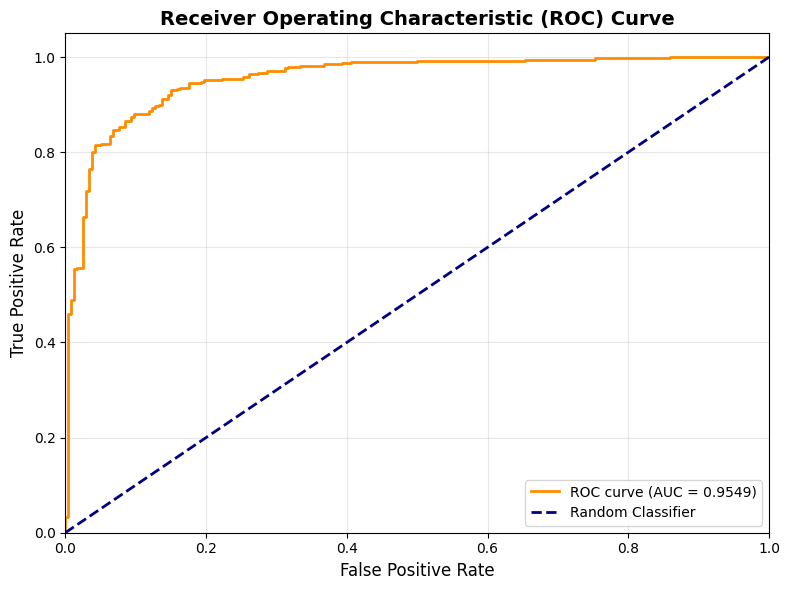


DETAILED PERFORMANCE METRICS
Sensitivity (Recall): 0.8692
Specificity: 0.9060
Positive Predictive Value (Precision): 0.9391
Negative Predictive Value: 0.8061
F1-Score: 0.9028
AUC-ROC: 0.9549


In [ ]:

#Evaluation & Visualitzation
def plot_training_history(history):
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
   
    axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
   
    axes[0, 1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0, 1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
  
    axes[1, 0].plot(history.history['auc'], label='Train AUC', linewidth=2)
    axes[1, 0].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
    axes[1, 0].set_title('Model AUC-ROC', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
   
    axes[1, 1].plot(history.history['precision'], label='Train Precision', linewidth=2)
    axes[1, 1].plot(history.history['recall'], label='Train Recall', linewidth=2)
    axes[1, 1].plot(history.history['val_precision'], label='Val Precision', linewidth=2, linestyle='--')
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall', linewidth=2, linestyle='--')
    axes[1, 1].set_title('Precision & Recall', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def evaluate_model(model, test_gen):
    
    print("\n" + "="*80)
    print("MODEL EVALUATION ON TEST SET")
    print("="*80)
    
    
    test_gen.reset()
    y_pred_probs = model.predict(test_gen, verbose=1)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    y_true = test_gen.classes
    
    print("\nClassification Report:")
    print("-"*60)
    print(classification_report(y_true, y_pred, target_names=Config.CLASSES, digits=4))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=Config.CLASSES, yticklabels=Config.CLASSES,
                cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)  
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp)  
    npv = tn / (tn + fn)
    f1 = 2 * (ppv * sensitivity) / (ppv + sensitivity)
    
    print("\n" + "="*80)
    print("DETAILED PERFORMANCE METRICS")
    print("="*80)
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Positive Predictive Value (Precision): {ppv:.4f}")
    print(f"Negative Predictive Value: {npv:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    
    return {
        'sensitivity': sensitivity,
        'specificity': specificity,
        'ppv': ppv,
        'npv': npv,
        'f1': f1,
        'auc': roc_auc
    }

best_model = keras.models.load_model(Config.MODEL_SAVE_PATH)
plot_training_history(history)
metrics = evaluate_model(best_model, test_gen)
